## **Artificial Neural Networks with Python**

> In the lecture, I do this:

> from numpy import *

> WARNING: It is generally considered bad

> programming style to "import *", as it

>can lead to confusion. For me, I

> (1) ALWAYS import numpy

> (2) NEVER import any other package in this * way

> Therefore, there is never confusion for me, and

> it makes my code a bit more readable (for me).

> However, since 99% of people are using the 

> syntax "import numpy as np" and then

> access "np.exp()" etc., you

> should probably also use "np" once you start

> exchanging code with others. I convert

> back to the np. syntax when I turn my

> converged code into a module.

> It is apparently officially accepted to explicitly

> list all the functions you need from numpy:


In [1]:
from numpy import array, zeros, exp, random, dot, shape, reshape, meshgrid, linspace
import matplotlib.pyplot as plt # for plotting
import matplotlib
matplotlib.rcParams['figure.dpi']=300 # highres display

# A very simple neural network (no hidden layer)

A network with N0 input neurons and N1 output neurons (no hidden layer)
 
$$y^{\rm out}_j = f(\sum_k w_{jk} y^{\rm in}_k + b_k)$$

where $w$ is the weight matrix, $b$ is the bias vector, and $f$ would be the activation function (e.g. the sigmoid here), which is applied independently for each $j$.


In [3]:
N0=3 # input layer size
N1=2 # output layer size

# initialize random weights: array dimensions N1xN0
w=random.uniform(low=-1,high=+1,size=(N1,N0))

# initialize random biases: N1 vector
b=random.uniform(low=-1,high=+1,size=N1)

In [4]:
# input values
y_in=array([0.2,0.4,-0.1])

### Activation function

> Sigmoid: $$ sigmoid(x)=\frac{1}{1+e^{x}}$$

> Tanh: $$tanh(x)$$

In [5]:
import numpy as np
# evaluate network by hand, in two steps
z=dot(w,y_in)+b # result: the vector of 'z' values, length N1


# Output layer aft applying the activation function:
y_out=1/(1+exp(-z)) # the 'sigmoid' function (applied elementwise)

y_out1=np.tanh(z) # the 'tanh' function (applied elementwise)  


In [6]:
print("network input y_in:", y_in) # input layer
print("weights w:", w)
print("bias vector b:", b)
print("linear superposition z:", z) #preactivation funnction
print("network output y_out:", y_out) #output layer after sigmoid activation

network input y_in: [ 0.2  0.4 -0.1]
weights w: [[-0.93625397  0.17263234 -0.30276771]
 [-0.05773866 -0.48570993 -0.15628099]]
bias vector b: [-0.88174202 -0.26376432]
linear superposition z: [-0.96966311 -0.45396792]
network output y_out: [0.27494766 0.38841777]


In [7]:
# print the dimensions of all the arrays we have created:
print("dimensions of w:", shape(w))
print("dimensions of b:", shape(b))
print("dimensions of z:", shape(z))
print("dimensions of y_out:", shape(y_out))
print("dimensions of y_in:", shape(y_in))

dimensions of w: (2, 3)
dimensions of b: (2,)
dimensions of z: (2,)
dimensions of y_out: (2,)
dimensions of y_in: (3,)


### Visualize network result

In [8]:
# a function that applies the neural network
def apply_net(y_in):
    global w, b
    
    z=dot(w,y_in)+b    # Recurssion relation
    return(1/(1+exp(-z))) # applied sigmoid
   

In [9]:
N0=2 # input layer size
N1=1 # output layer size

w=random.uniform(low=-10,high=+10,size=(N1,N0)) # random weights: N1xN0
b=random.uniform(low=-1,high=+1,size=N1) # biases: N1 vector


In [10]:
# the input is : Y_in=[0.8,0.3]
apply_net([0.8,0.3]) # a simple test

array([2.29870243e-05])

In [13]:
M=50 # will create picture of size MxM
y_out=zeros([M,M]) # array MxM, to hold the result

for j1 in range(M):
    for j2 in range(M):
        # out of these integer indices, generate
        # two values in the range -0.5...0.5
        # and then apply the network to those two
        # input values
        value0=float(j1)/M-0.5
        value1=float(j2)/M-0.5
        y_out[j1,j2]=apply_net([value0,value1])[0]

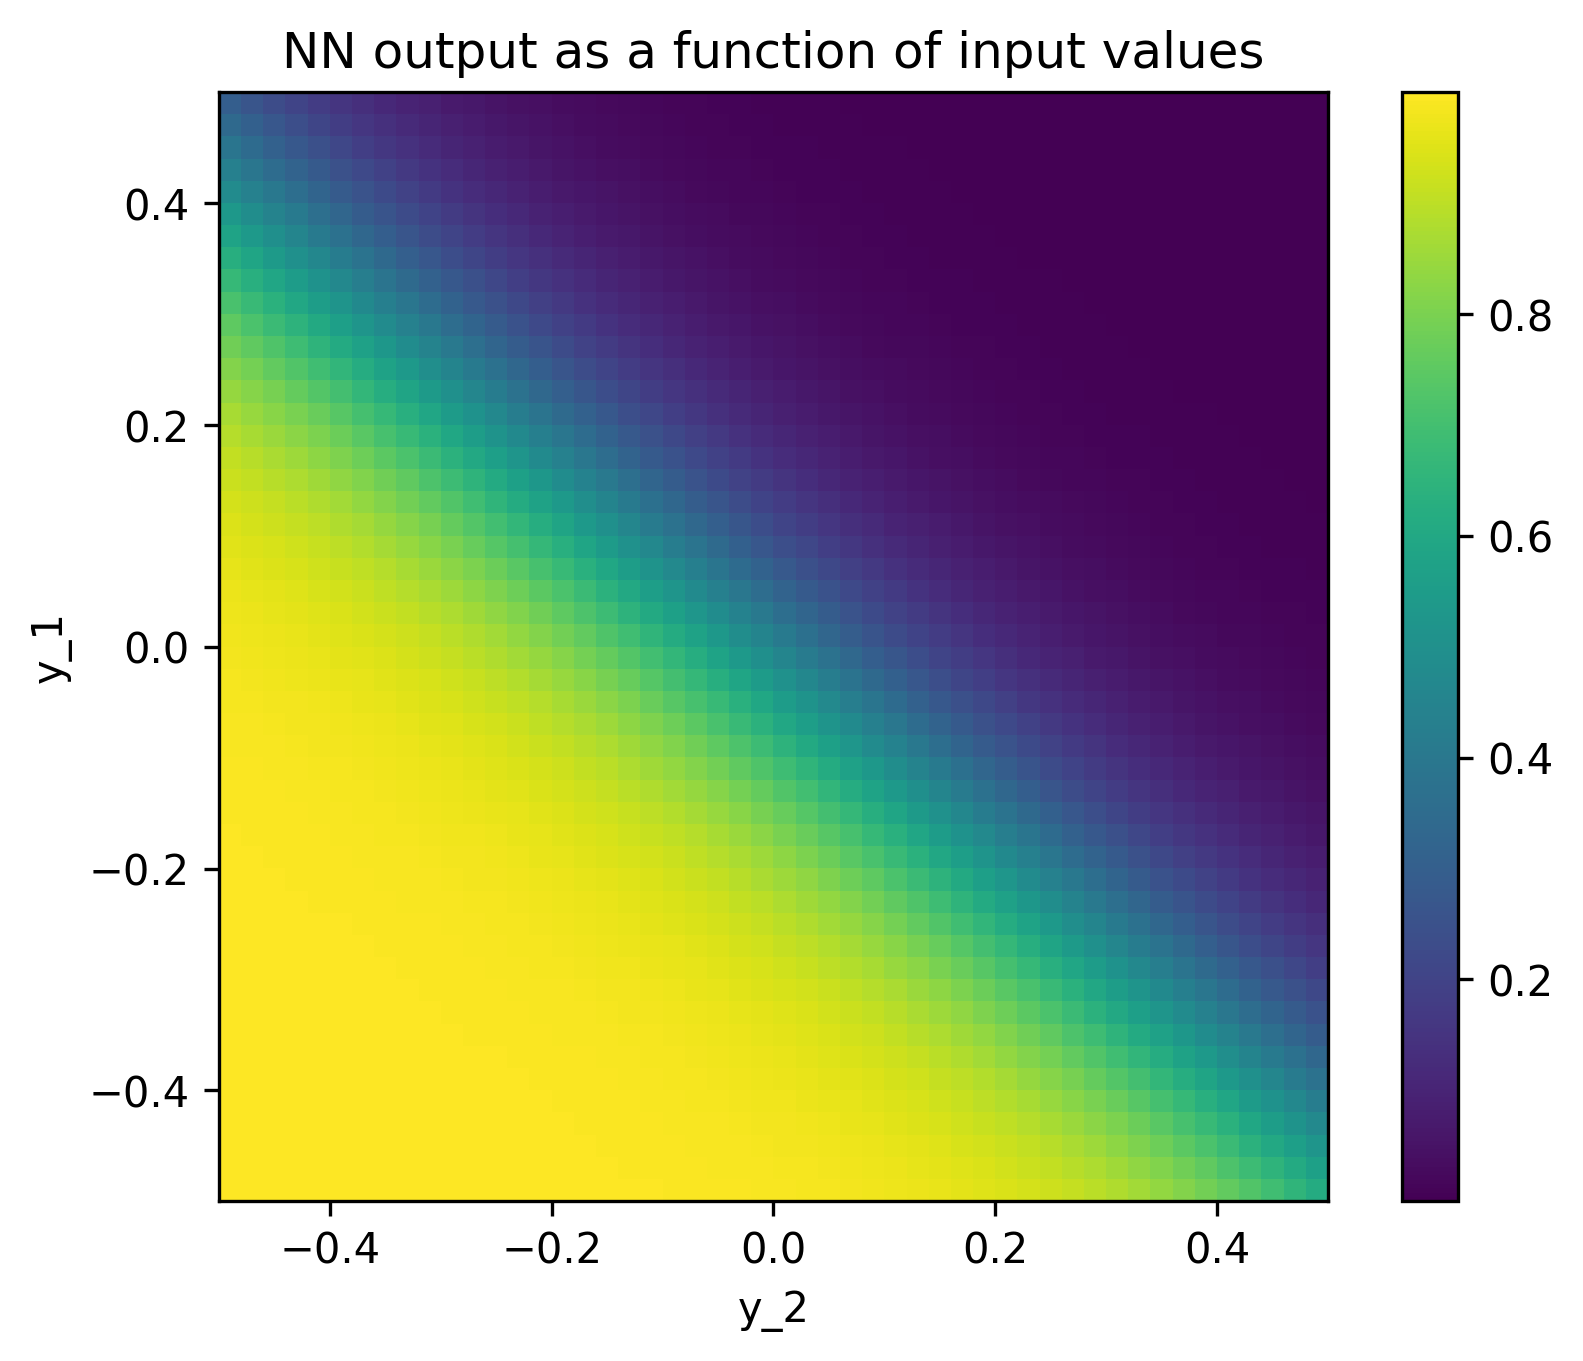

In [14]:
# display image
plt.imshow(y_out,origin='lower',extent=(-0.5,0.5,-0.5,0.5))
plt.colorbar()
plt.title("NN output as a function of input values")
plt.xlabel("y_2")
plt.ylabel("y_1")
plt.show()

In [15]:
# a function that evaluates one layer based
# on the neuron values in the preceding layer
def apply_layer(y_in,w,b): 
    z=dot(w,y_in)+b
    return(1/(1+exp(-z)))

In [16]:
N0=2 # input layer size
N1=30 # hidden layer size
N2=1 # output layer size

# weights and biases
# from input layer to hidden layer:
w1=random.uniform(low=-10,high=+10,size=(N1,N0)) # random weights: N1xN0
b1=random.uniform(low=-1,high=+1,size=N1) # biases: N1 vector

# weights+biases from hidden layer to output layer:
w2=random.uniform(low=-10,high=+10,size=(N2,N1)) # random weights
b2=random.uniform(low=-1,high=+1,size=N2) # biases

In [17]:
def apply_net(y_in):
    global w1,b1,w2,b2
    
    y1=apply_layer(y_in,w1,b1) # from input --> hidden layer
    y2=apply_layer(y1,w2,b2) # from hidden --> output layer
    return(y2)

In [18]:
M=50 # will create picture of size MxM
y_out=zeros([M,M]) # array MxM, to hold the result

for j1 in range(M):
    for j2 in range(M):
        value0=float(j1)/M-0.5
        value1=float(j2)/M-0.5
        y_out[j1,j2]=apply_net([value0,value1])[0]

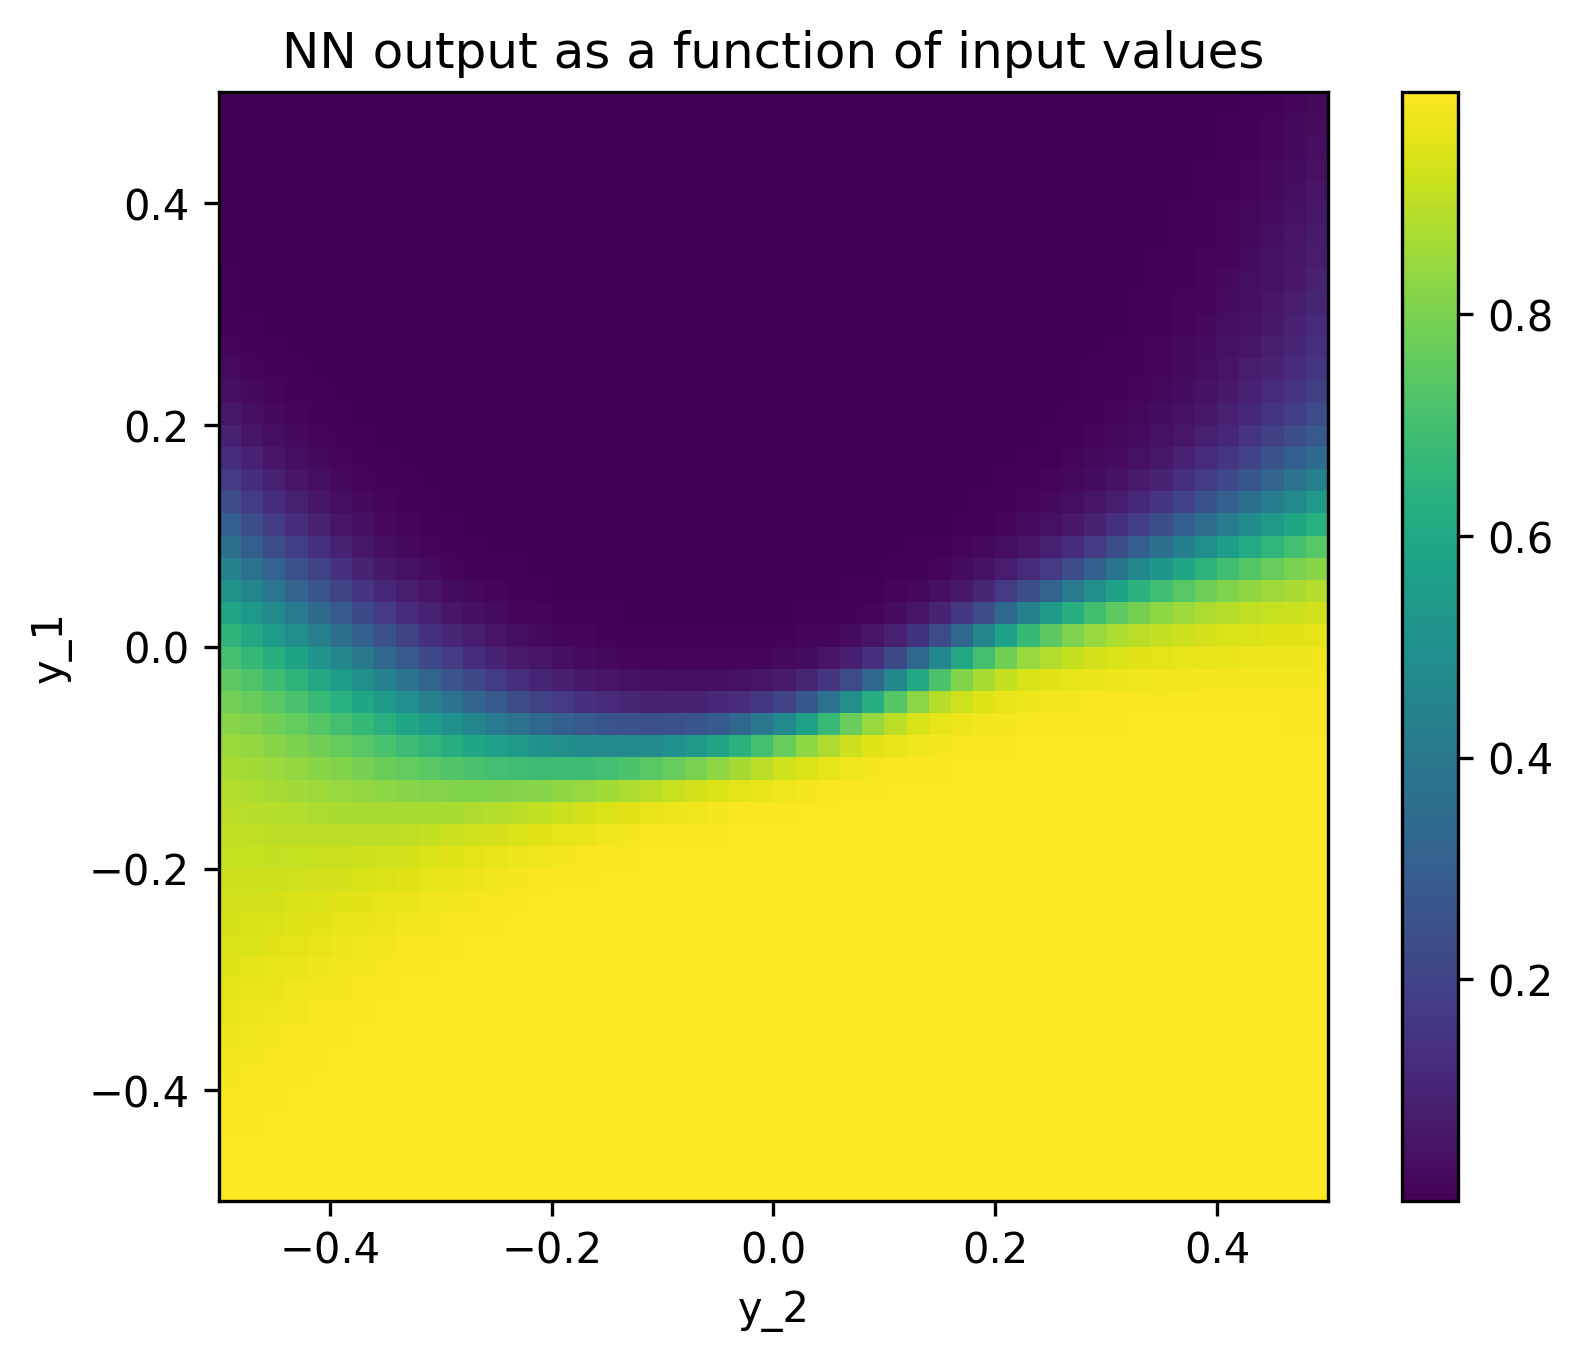

In [19]:
# display image
plt.imshow(y_out,origin='lower',extent=(-0.5,0.5,-0.5,0.5))
plt.colorbar()
plt.title("NN output as a function of input values")
plt.xlabel("y_2")
plt.ylabel("y_1")
plt.show()

### For fun: a network with MANY hidden layers

In [20]:
Nlayers=20 # number of hidden layers: not counting the input layer & the output layer
LayerSize=100 # the number of neurones in each hidden layer

Weights=random.uniform(low=-3,high=3,size=[Nlayers,LayerSize,LayerSize])
Biases=random.uniform(low=-1,high=1,size=[Nlayers,LayerSize])

# for the first hidden layer (coming in from the input layer)
WeightsFirst=random.uniform(low=-1,high=1,size=[2,LayerSize])
BiasesFirst=random.uniform(low=-1,high=1,size=LayerSize)

# for the final layer (i.e. the output neuron)
WeightsFinal=random.uniform(low=-1,high=1,size=[LayerSize,1])
BiasesFinal=random.uniform(low=-1,high=1,size=1)

In [21]:
def apply_layer_new(y_in,w,b): # a function that applies a layer    
    z=dot(y_in,w)+b # note different order in matrix product!
    return(1/(1+exp(-z)))

In [22]:
def apply_net_new(y_in): # same as before, but with new layer function
    global w1,b1,w2,b2
    
    y1=apply_layer_new(y_in,w1,b1)
    y2=apply_layer_new(y1,w2,b2)
    return(y2)

In [23]:
def apply_multi_net(y_in):
    global Weights, Biases, WeightsFinal, BiasesFinal, Nlayers
    
    y=apply_layer_new(y_in,WeightsFirst,BiasesFirst)    
    for j in range(Nlayers):
        y=apply_layer_new(y,Weights[j,:,:],Biases[j,:])
    output=apply_layer_new(y,WeightsFinal,BiasesFinal)
    return(output)

In [24]:
# Generate a 'mesh grid', i.e. x,y values in an image
M=40
v0,v1=meshgrid(linspace(-0.5,0.5,M),linspace(-0.5,0.5,M))
batchsize=M**2 # number of samples = number of pixels = M^2
y_in=zeros([batchsize,2])
y_in[:,0]=v0.flatten() # fill first component (index 0)
y_in[:,1]=v1.flatten() # fill second component

In [25]:
# use the MxM input grid that we generated above 
y_out=apply_multi_net(y_in) # apply net to all these samples!

In [26]:
y_2D=reshape(y_out[:,0],[M,M]) # back to 2D image

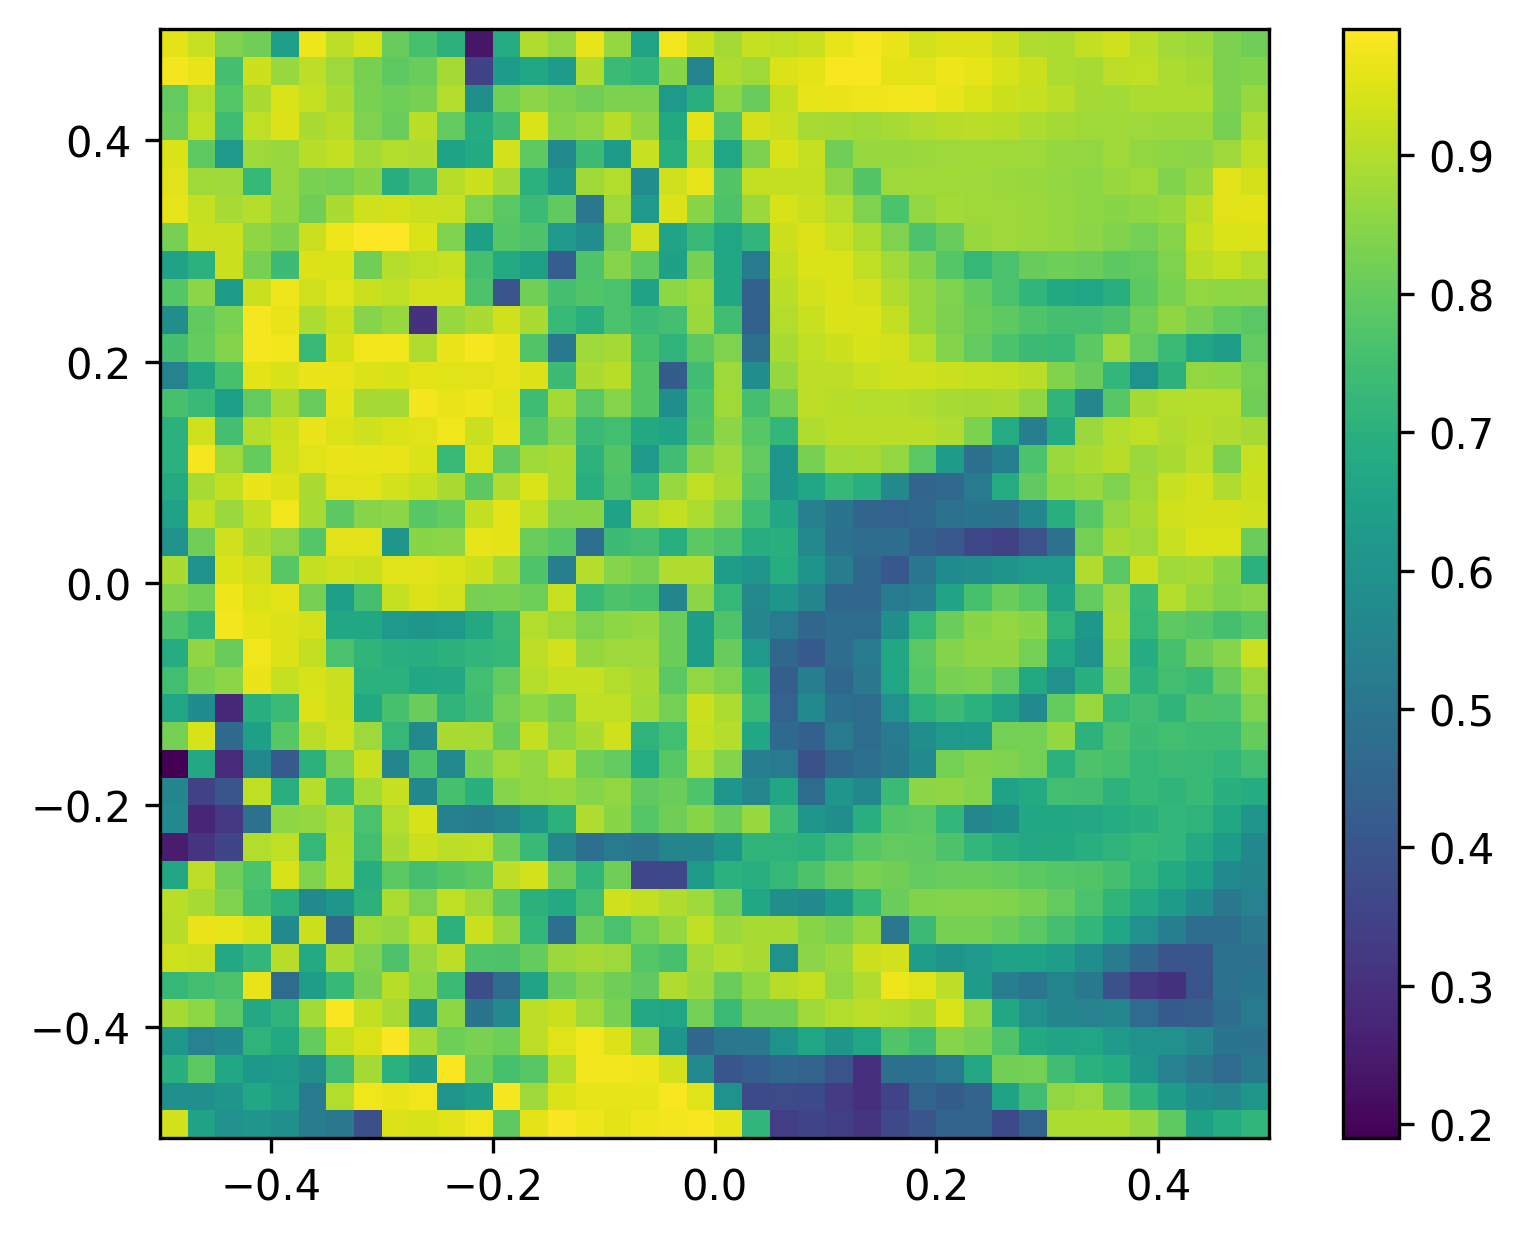

In [27]:
plt.imshow(y_2D,origin='lower',extent=[-0.5,0.5,-0.5,0.5],interpolation='nearest')
plt.colorbar()
plt.show()

In [28]:
M=400
# Generate a 'mesh grid', i.e. x,y values in an image
v0,v1=meshgrid(linspace(-0.5,0.5,M),linspace(-0.5,0.5,M))
batchsize=M**2 # number of samples = number of pixels = M^2
y_in=zeros([batchsize,2])
y_in[:,0]=v0.flatten() # fill first component (index 0)
y_in[:,1]=v1.flatten() # fill second component

In [29]:
y_out=apply_multi_net(y_in)

In [30]:
y_2D=reshape(y_out[:,0],[M,M])

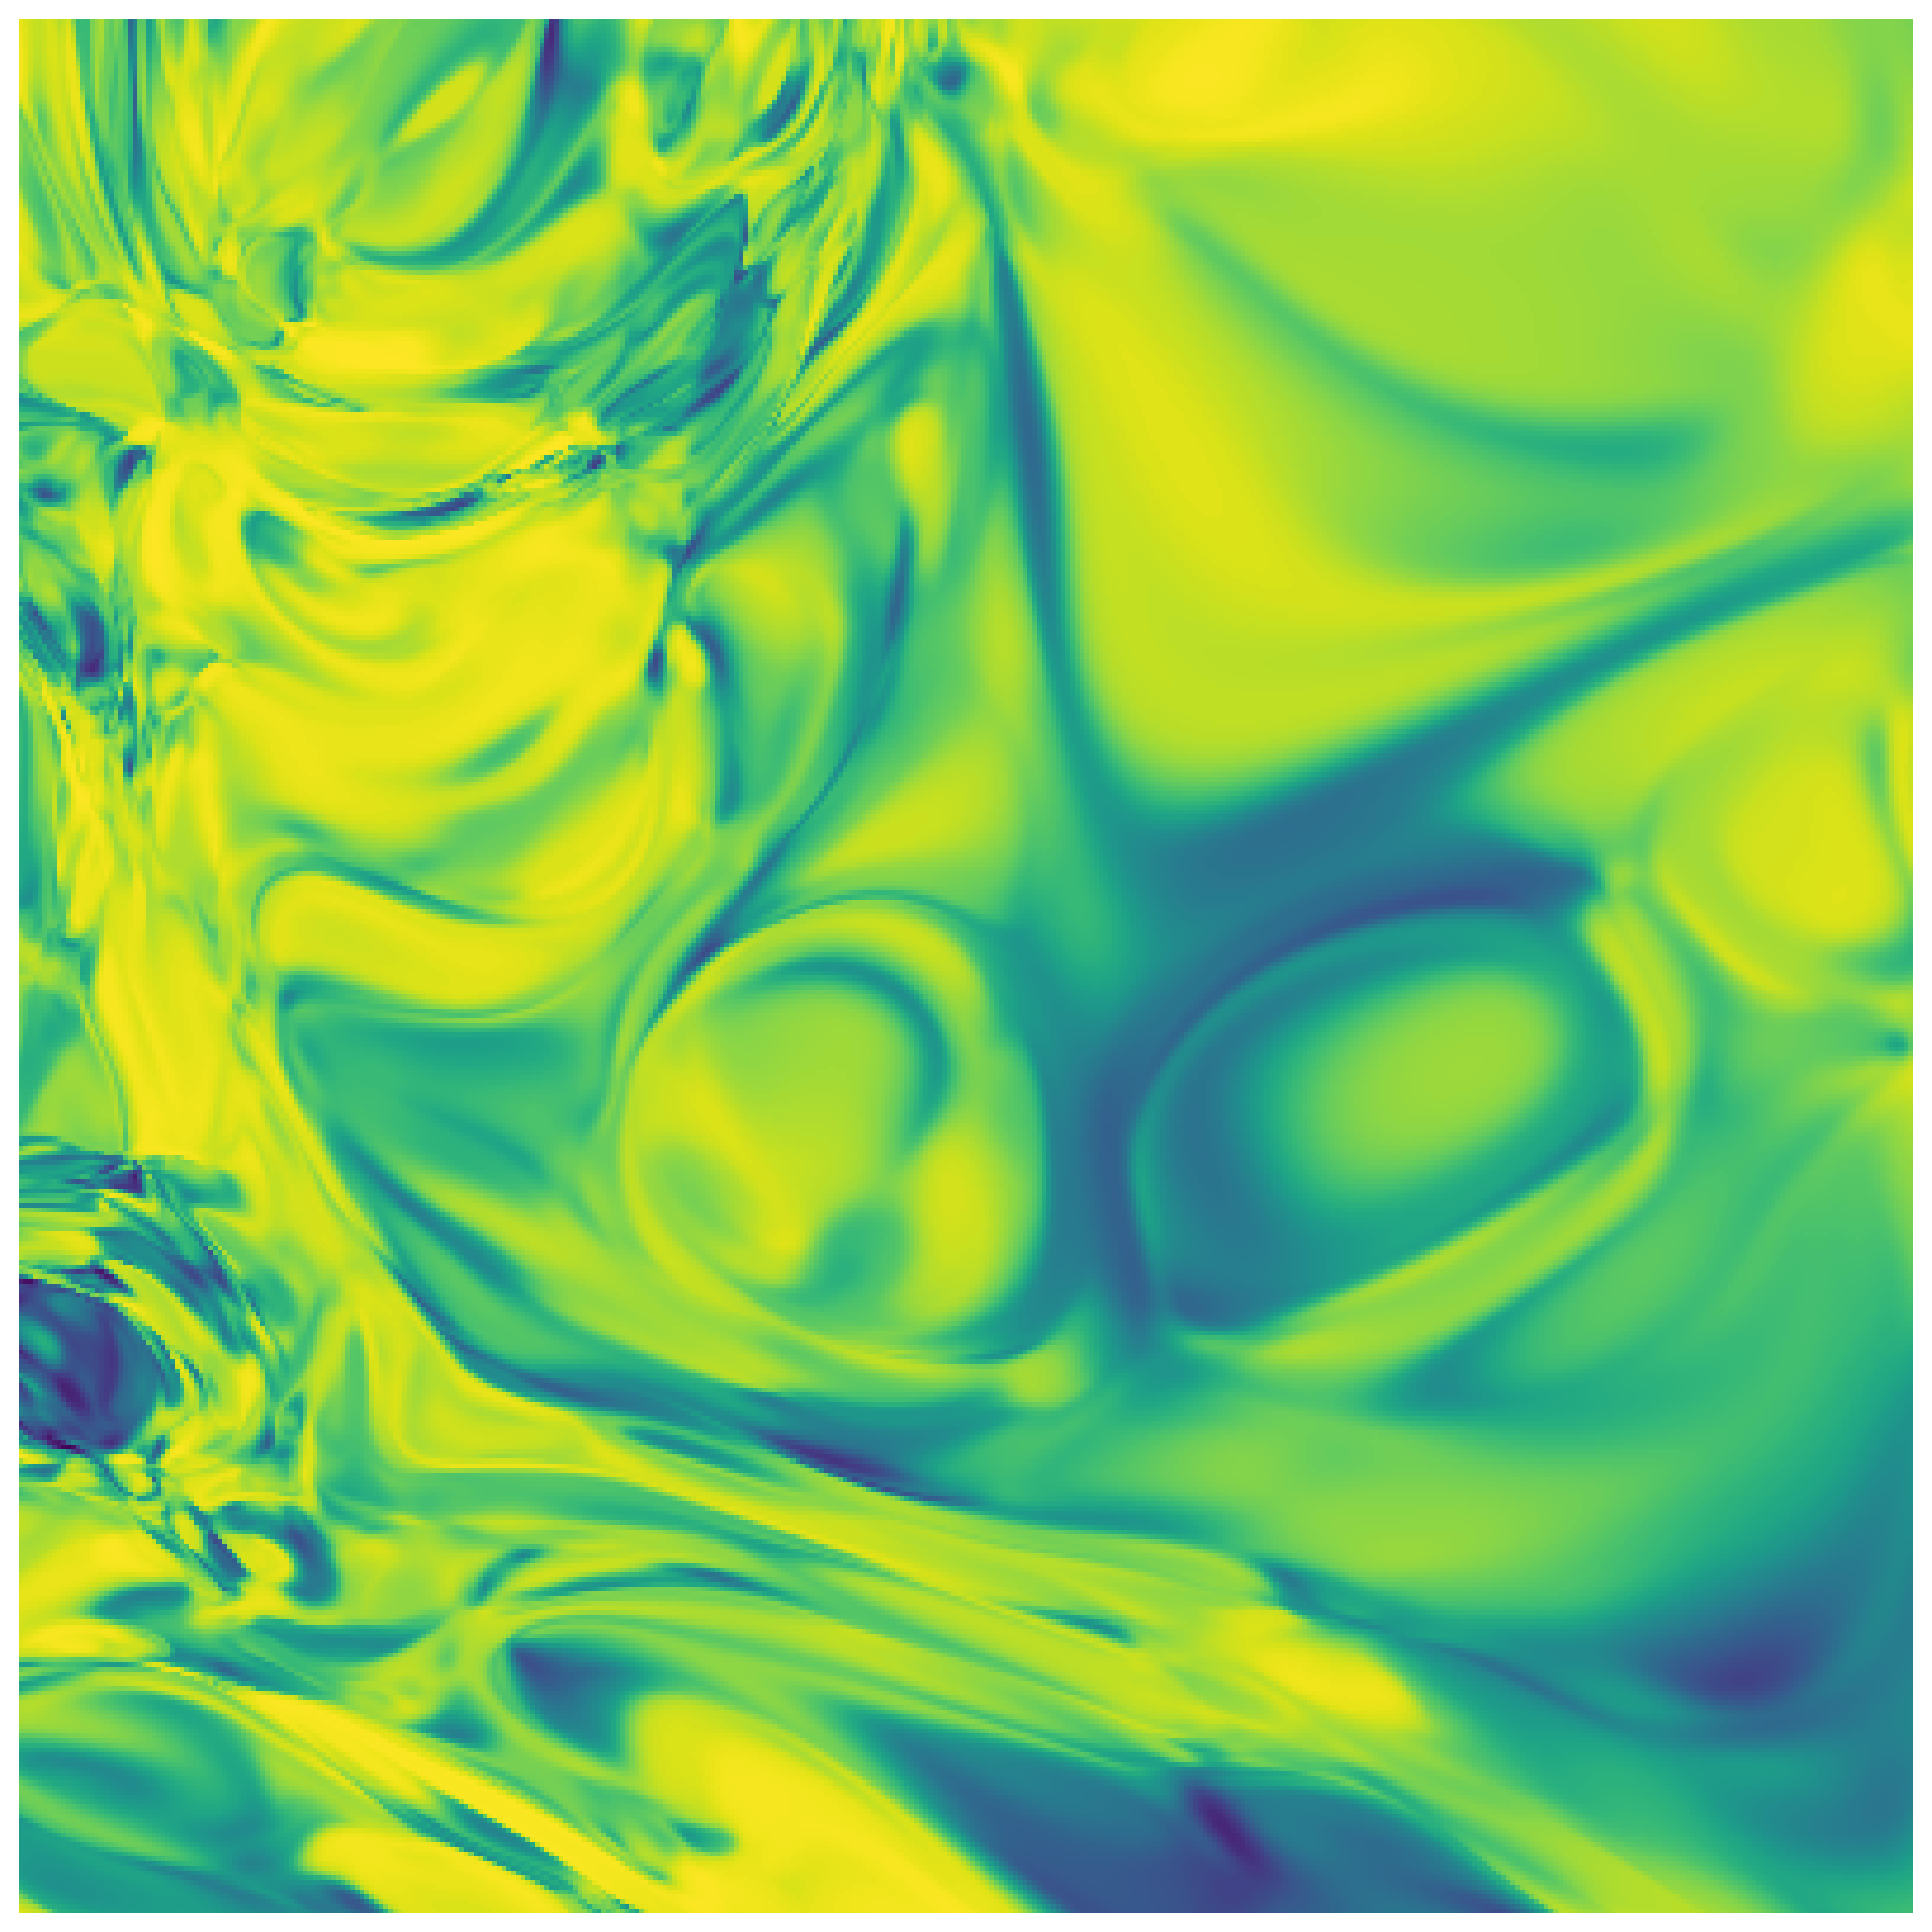

In [31]:
plt.figure(figsize=[10,10])
plt.axes([0,0,1,1]) # fill all of the picture with the image
plt.imshow(y_2D,origin='lower',extent=[-0.5,0.5,-0.5,0.5],interpolation='nearest')
plt.axis('off') # no axes
plt.show()

In [ ]:
# def mc(y_in):
#     global w, b

#     z=dot(w,y_in)+b    # Recurssion relation

#     return np.tanh(z)